In [345]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit.visualization import *
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.quantum_info import Statevector
from numpy import pi
import numpy as np
from matplotlib import pyplot as plt

# Aer is now a separate package (qiskit-aer)
from qiskit_aer import AerSimulator

In [ ]:
Q = 128  #Give the value of Q such that The grid will be QxQ must be in 2^x

In [347]:
N = Q*Q # Total Number of vertex in the grid
l = 4/N # Valule for self loop

In [348]:
# Compute coefficients of the coin
a = 2 / (4 + l)
b = 2 * np.sqrt(l) / (4 + l)
c = 2 * l / (4 + l)

In [349]:
C5 = np.array([
    [a - 1,  a,      a,      a,      b],
    [a,      a - 1,  a,      a,      b],
    [a,      a,      a - 1,  a,      b],
    [a,      a,      a,      a - 1,  b],
    [b,      b,      b,      b,      c - 1]
], dtype=complex)

# Embed into an 8x8 matrix for 3 qubits
C8 = np.zeros((8, 8), dtype=complex)
C8[:5, :5] = C5  # top-left block
for i in range(5, 8):
    C8[i, i] = 1

# Creating the gate for Coin
coin_gate = UnitaryGate(C8, label="Coin")

In [350]:
from qiskit.circuit.library import StatePreparation

coin_init = np.zeros(8, dtype=complex)
coin_init[0] = 1 / np.sqrt(4 + l)           # 000
coin_init[1] = 1 / np.sqrt(4 + l)           # 001
coin_init[2] = 1 / np.sqrt(4 + l)           # 010
coin_init[3] = 1 / np.sqrt(4 + l)           # 011
coin_init[4] = np.sqrt(l) / np.sqrt(4 + l)  # 100

coin_prep = StatePreparation(coin_init)

In [351]:
coin = QuantumRegister(3,'coin')
nodeX = QuantumRegister(int(np.log2(Q)),'vertex_X')
nodeY = QuantumRegister(int(np.log2(Q)),'vertex_y')
classR = ClassicalRegister(int(2*np.log2(Q)),'measure')

one_step = QuantumCircuit(nodeX, nodeY, coin,  classR, name='ONE_STEP')

In [352]:
#phase oracle 
A = 2 * int(np.log2(Q))
phase_circuit =  QuantumCircuit(A, name=' phase oracle ')
# Mark 100000 for any code 
cont = []
for i in range(0,A-1):
    phase_circuit.x(i)
    cont.append(i)
phase_circuit.h(A-1)
phase_circuit.mcx(cont,A-1)
phase_circuit.h(A-1)
for i in range(0,A-1):
    phase_circuit.x(i)
    cont.append(i)
phase_circuit.draw()

┌───┐     ┌───┐
 q_0: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_1: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_2: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_3: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_4: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_5: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_6: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_7: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_8: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
 q_9: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
q_10: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
q_11: ┤ X ├──■──┤ X ├
      ├───┤  │  ├───┤
q_12: ┤ X ├──■──┤ X ├
      ├───┤┌─┴─┐├───┤
q_13: ┤ H ├┤ X ├┤ H ├
      └───┘└───┘└───┘

In [353]:
def superposition(circuit, Q):
    num_states = int(2*np.log2(Q))
    for i in range(0,num_states):
        circuit.h(i)


In [354]:
superposition(one_step,Q)

In [355]:
one_step.append(coin_prep, coin)

one_step.append(coin_gate, coin) # 000 + 001 + 010 + 011 + 100

one_step.draw()


»
vertex_X_0: »
            »
vertex_X_1: »
            »
vertex_X_2: »
            »
vertex_X_3: »
            »
vertex_X_4: »
            »
vertex_X_5: »
            »
vertex_X_6: »
            »
vertex_y_0: »
            »
vertex_y_1: »
            »
vertex_y_2: »
            »
vertex_y_3: »
            »
vertex_y_4: »
            »
vertex_y_5: »
            »
vertex_y_6: »
            »
    coin_0: »
            »
    coin_1: »
            »
    coin_2: »
            »
measure: 14/»
            »
«                                             ┌───┐                                 »
«vertex_X_0: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_1: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_2: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_3: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_4: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_5: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_6: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_0: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_1: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_2: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_3: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_4: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_5: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_6: ─────────────────────────────────┤ H ├─────────────────────────────────»
«            ┌────────────────────────────────┴───┴────────────────────────────────┐»
«    coin_0: ┤0                                                                    ├»
«            │                                                                     │»
«    coin_1: ┤1 State Preparation(0.49998,0.49998,0.49998,0.49998,0.0078123,0,0,0) ├»
«            │                                                                     │»
«    coin_2: ┤2                                                                    ├»
«            └─────────────────────────────────────────────────────────────────────┘»
«measure: 14/═══════════════════════════════════════════════════════════════════════»
«                                                                                   »
«                     
«vertex_X_0: ─────────
«                     
«vertex_X_1: ─────────
«                     
«vertex_X_2: ─────────
«                     
«vertex_X_3: ─────────
«                     
«vertex_X_4: ─────────
«                     
«vertex_X_5: ─────────
«                     
«vertex_X_6: 

In [356]:
def shift(circuit, Q):
    num_states = 3 + int(2*np.log2(Q))
    circuit.x(num_states-3)
    circuit.x(num_states-2)
    circuit.x(num_states-1)
    E = int(np.log2(Q))
    D = E
    for i in range(int(np.log2(Q))):
        x = list(range(0,E-1))
        x.append(num_states-1)
        x.append(num_states-2)
        x.append(num_states-3)
        circuit.mcx(x,E-1)
        E = E-1
    circuit.x(num_states-3)
    for i in range(int(np.log2(Q))):
        x = list(range(0,E))
        x.append(num_states-1)
        x.append(num_states-2)
        x.append(num_states-3)
        circuit.mcx(x,E)
        E = E+1
    circuit.x(num_states-3)
    circuit.x(num_states-2)
    E = 2*int(np.log2(Q))
    for i in range(int(np.log2(Q))):
        x = list(range(D,E-1))
        x.append(num_states-1)
        x.append(num_states-2)
        x.append(num_states-3)
        circuit.mcx(x,E-1)
        E = E-1
    circuit.x(num_states-3)
    for i in range(int(np.log2(Q))):
        x = list(range(D,E))
        x.append(num_states-1)
        x.append(num_states-2)
        x.append(num_states-3)
        circuit.mcx(x,E)
        E = E+1
    circuit.x(num_states-1)
    circuit.x(num_states-1)
    circuit.mcx([num_states-1],num_states-3)
    circuit.x(num_states-1)



In [357]:
shift(one_step,Q)


In [358]:
one_step.draw()

»
vertex_X_0: »
            »
vertex_X_1: »
            »
vertex_X_2: »
            »
vertex_X_3: »
            »
vertex_X_4: »
            »
vertex_X_5: »
            »
vertex_X_6: »
            »
vertex_y_0: »
            »
vertex_y_1: »
            »
vertex_y_2: »
            »
vertex_y_3: »
            »
vertex_y_4: »
            »
vertex_y_5: »
            »
vertex_y_6: »
            »
    coin_0: »
            »
    coin_1: »
            »
    coin_2: »
            »
measure: 14/»
            »
«                                             ┌───┐                                 »
«vertex_X_0: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_1: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_2: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_3: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_4: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_5: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_X_6: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_0: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_1: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_2: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_3: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_4: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_5: ─────────────────────────────────┤ H ├─────────────────────────────────»
«                                             ├───┤                                 »
«vertex_y_6: ─────────────────────────────────┤ H ├─────────────────────────────────»
«            ┌────────────────────────────────┴───┴────────────────────────────────┐»
«    coin_0: ┤0                                                                    ├»
«            │                                                                     │»
«    coin_1: ┤1 State Preparation(0.49998,0.49998,0.49998,0.49998,0.0078123,0,0,0) ├»
«            │                                                                     │»
«    coin_2: ┤2                                                                    ├»
«            └─────────────────────────────────────────────────────────────────────┘»
«measure: 14/═══════════════════════════════════════════════════════════════════════»
«                                                                                   »
«                                                        ┌───┐     ┌───┐     »
«vertex_X_0: ────────────────■────■────■────■────■────■──┤ X ├─────┤ X ├──■──»
«                            │    │    │    │    │  ┌─┴─┐└─┬─┘     └─┬─┘┌─┴─┐»
«vertex_X_1: ────────────────■────■────■────■────■──┤ X ├──┼─────────┼──┤ X

In [359]:
import numpy as np
x =  0.922466 * np.sqrt((N)*(np.log2(N)))

In [360]:
for i in range(int(x-2)):
    num_states = 3 + int(2*np.log2(Q))
    coin_states = [num_states-3, num_states-2, num_states-1]
    one_step.append(coin_gate,coin_states)
    shift(one_step,Q)
    vertex = list(range(0,num_states-3))
    one_step.append(phase_circuit,vertex)
one_step.measure(vertex,vertex)

In [ ]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

job = sampler.run([one_step], shots=1000)

result = job.result()

In [ ]:
print(dir(result[0].data))

['_FIELDS', '_FIELD_TYPES', '_RESTRICTED_NAMES', '_SHAPE', '__abstractmethods__', '__annotate_func__', '__annotations__', '__annotations_cache__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__non_callable_proto_members__', '__parameters__', '__protocol_attrs__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_data', '_is_protocol', '_is_runtime_protocol', '_shape', 'items', 'keys', 'measure', 'ndim', 'shape', 'size', 'values']


In [ ]:
counts = result[0].data.measure.get_counts()
print(counts)

{'100000000000': 865, '100100000000': 1, '011110000010': 1, '101011111111': 1, '100010001101': 1, '011111000100': 1, '100000111101': 1, '100111111111': 1, '000000101111': 1, '011011110101': 1, '100000110010': 1, '011110111101': 1, '011101000010': 1, '110001111011': 1, '011111000011': 1, '101110110111': 1, '100001000000': 13, '011001110111': 1, '011010110010': 1, '101001110011': 1, '100001111110': 1, '011100111000': 1, '011111000001': 2, '100000111010': 1, '011111000000': 8, '111001111100': 1, '100000000011': 1, '100110001111': 1, '100100111101': 1, '110010001010': 1, '101011000001': 1, '100011001001': 1, '010111111100': 1, '101010101000': 1, '100101001011': 1, '011110111110': 1, '100000111111': 5, '011111111111': 1, '011001000110': 1, '011110000011': 1, '011010001100': 1, '100011110011': 1, '011111111110': 1, '101010110101': 1, '100100000001': 1, '101000111101': 1, '100101111100': 1, '100001000001': 3, '011100000010': 1, '110010000110': 1, '100000000001': 5, '100100000010': 1, '1000100

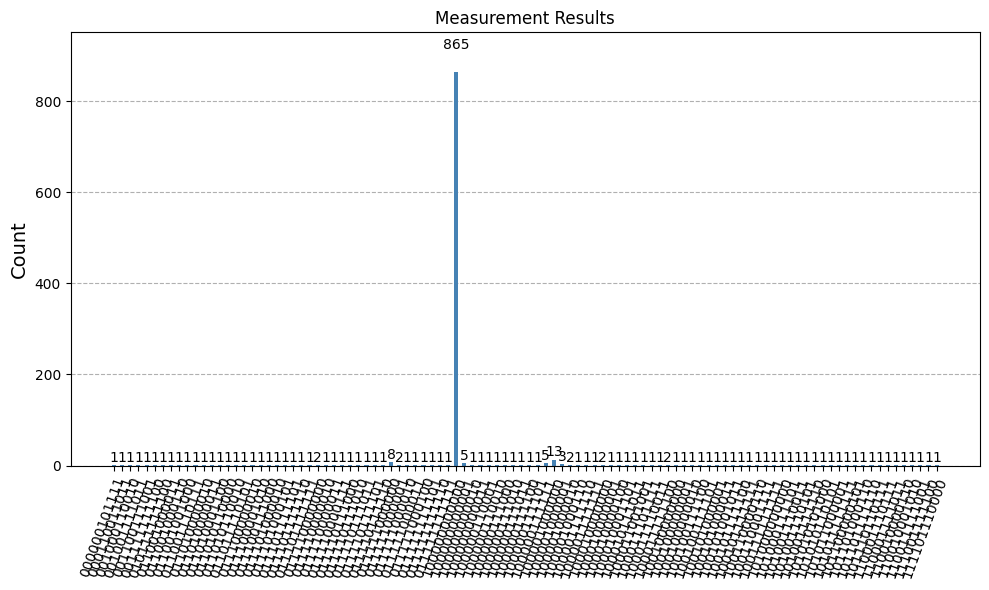

In [ ]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(counts, title='Measurement Results', figsize=(10, 6), color='steelblue')
fig.savefig(f'histogram{Q}x{Q}.png', dpi=300, bbox_inches='tight')